<a href="https://www.kaggle.com/code/adegbaju/cyber-security-attack-detection-using-network?scriptVersionId=327088368" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Cyber Security Attack Detection Using Network Traffic

#  Introduction
 
 This notebook demonstrates a complete machine learning pipeline for network intrusion detection using the **Cyber Security Attack Dataset** (synthetic, 100,000 records).  
 The goal is to classify network flows into one of four categories: **Normal**, **DDoS**, **BruteForce**, and **PortScan**.
 
 We will perform:
 - Exploratory Data Analysis (EDA)
 - Feature preprocessing (encoding, scaling)
 - Multi‑class classification with several algorithms
 - Model evaluation and comparison
 - Feature importance analysis


 *DO NOT FORGET TO UPVOTE*

# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.metrics import classification_report, confusion_matrix
import json
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings('ignore')

# Set style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


#  Load the Dataset

In [2]:
# For local execution, assume the file is in the current directory.
DATA_PATH = "/kaggle/input/datasets/juanschafle/cyber-attack-detection-using-network-traffic/cyber_attack_dataset_100000.csv" 
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (100000, 7)


,duration,src_bytes,dst_bytes,packet_count,protocol,failed_logins,attack_type
0,1,8605,418,631,TCP,0,DDoS
1,1,499,148,131,UDP,0,PortScan
2,10,370,160,105,UDP,0,PortScan
3,2,5138,320,666,TCP,0,DDoS
4,36,524,467,58,UDP,10,BruteForce


#  Exploratory Data Analysis (EDA)


In [3]:
# Basic info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   duration       100000 non-null  int64 
 1   src_bytes      100000 non-null  int64 
 2   dst_bytes      100000 non-null  int64 
 3   packet_count   100000 non-null  int64 
 4   protocol       100000 non-null  object
 5   failed_logins  100000 non-null  int64 
 6   attack_type    100000 non-null  object
dtypes: int64(5), object(2)
memory usage: 5.3+ MB


In [4]:
# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
duration         0
src_bytes        0
dst_bytes        0
packet_count     0
protocol         0
failed_logins    0
attack_type      0
dtype: int64


In [5]:
# Statistical summary of numeric features
df.describe()

,duration,src_bytes,dst_bytes,packet_count,failed_logins
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,16.462720,2219.62870,426.171030,202.550770,1.630520
std,15.632207,2751.14241,466.528205,249.729802,3.045577
min,1.000000,50.00000,20.000000,5.000000,0.000000
25%,4.000000,341.00000,131.000000,37.000000,0.000000
50%,10.000000,781.00000,256.000000,87.000000,0.000000
75%,28.000000,3024.00000,458.000000,257.000000,3.000000
max,60.000000,10000.00000,2000.000000,1000.000000,10.000000


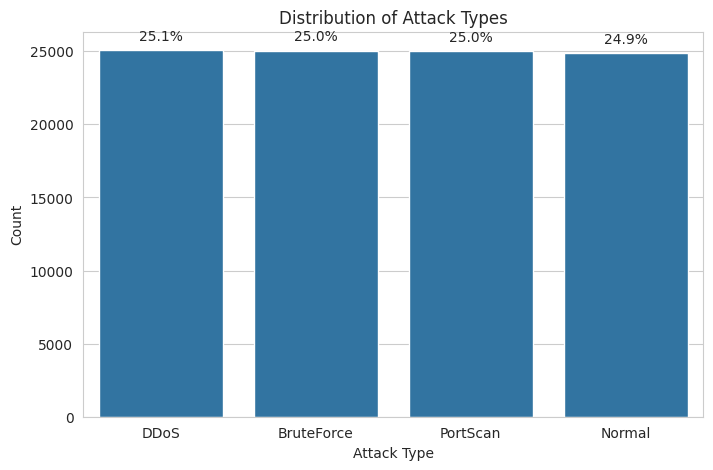

In [6]:
# Target class distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='attack_type', order=df['attack_type'].value_counts().index)
plt.title('Distribution of Attack Types')
plt.xlabel('Attack Type')
plt.ylabel('Count')
# Add percentage labels
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()

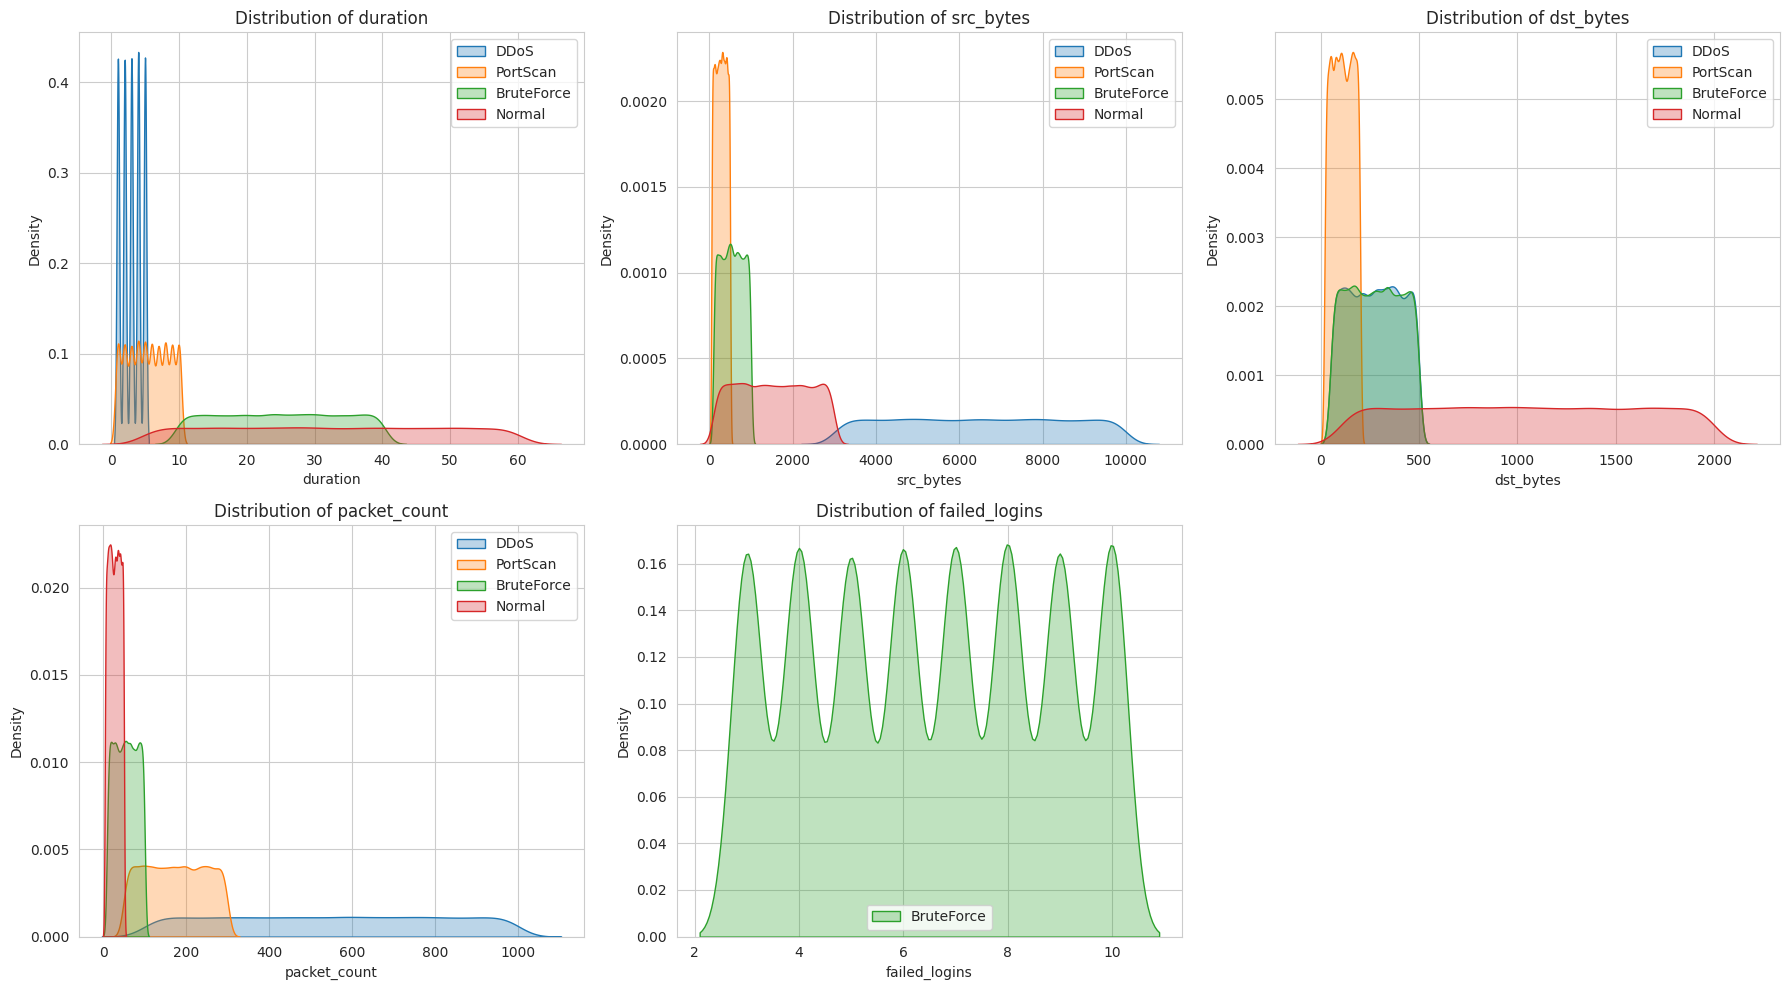

In [7]:
# Distribution of numeric features by class
numeric_features = ['duration', 'src_bytes', 'dst_bytes', 'packet_count', 'failed_logins']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_features):
    for attack in df['attack_type'].unique():
        sns.kdeplot(df[df['attack_type'] == attack][col], label=attack, ax=axes[i], fill=True, alpha=0.3)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].legend()
# Remove empty subplot if any
for j in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

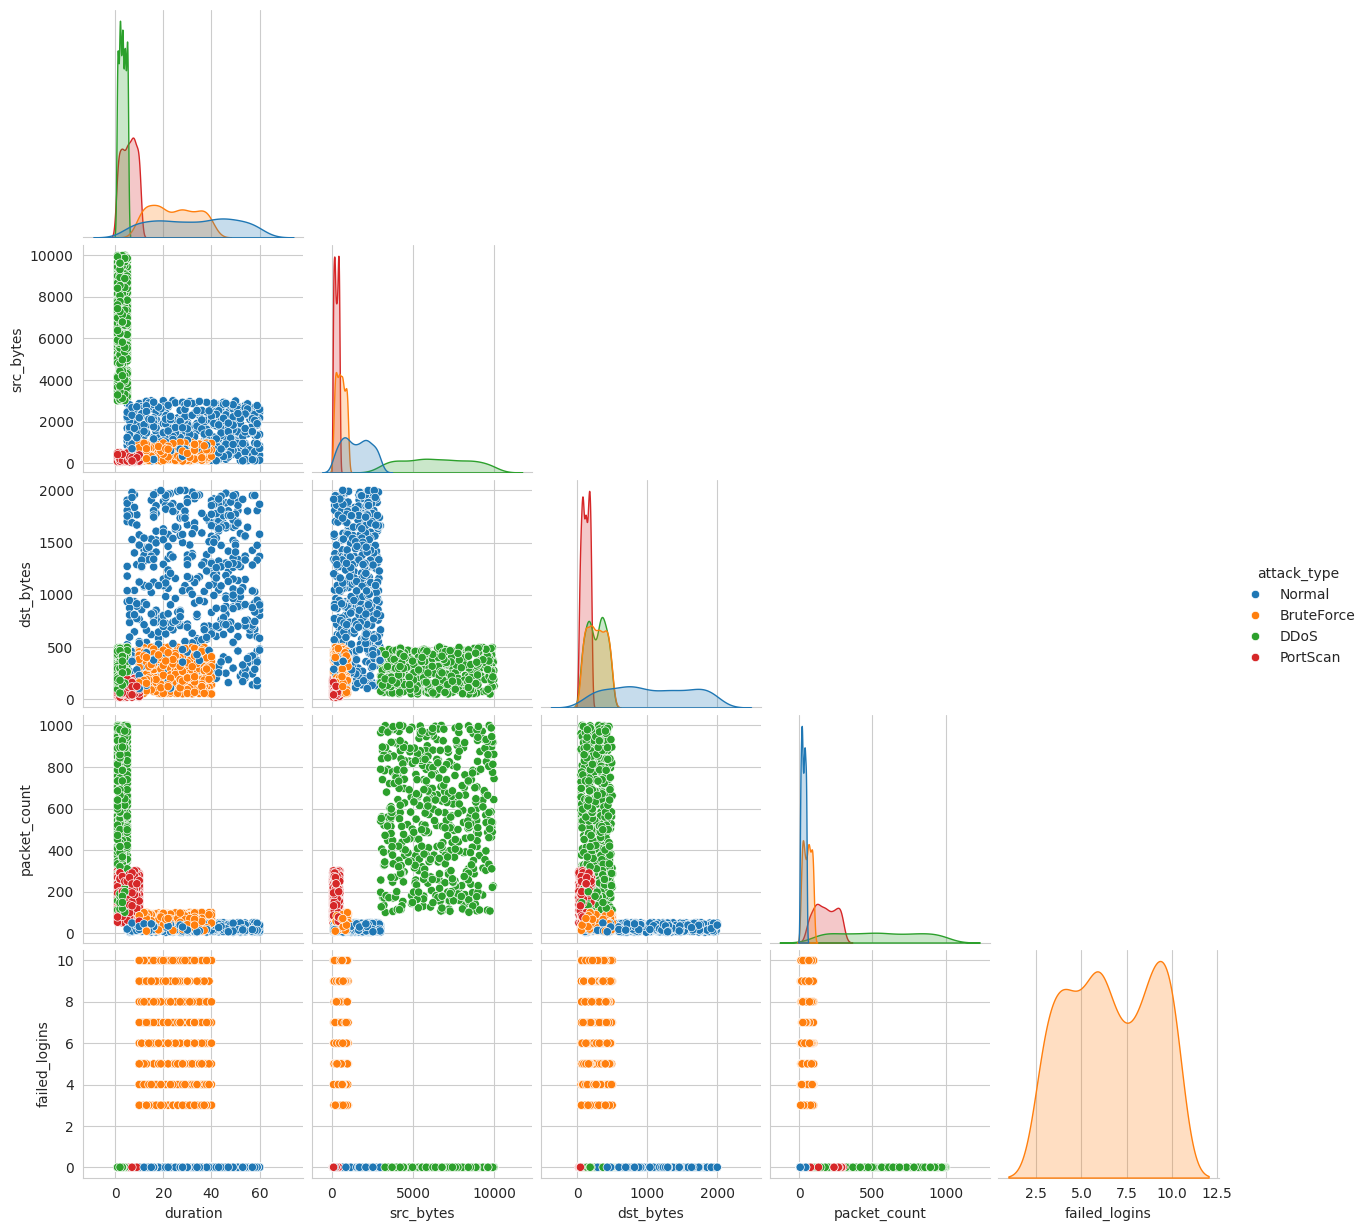

In [8]:
# Pairplot (sample to speed up)
sample_df = df.sample(2000, random_state=42)
sns.pairplot(sample_df, hue='attack_type', diag_kind='kde', corner=True)
plt.show()

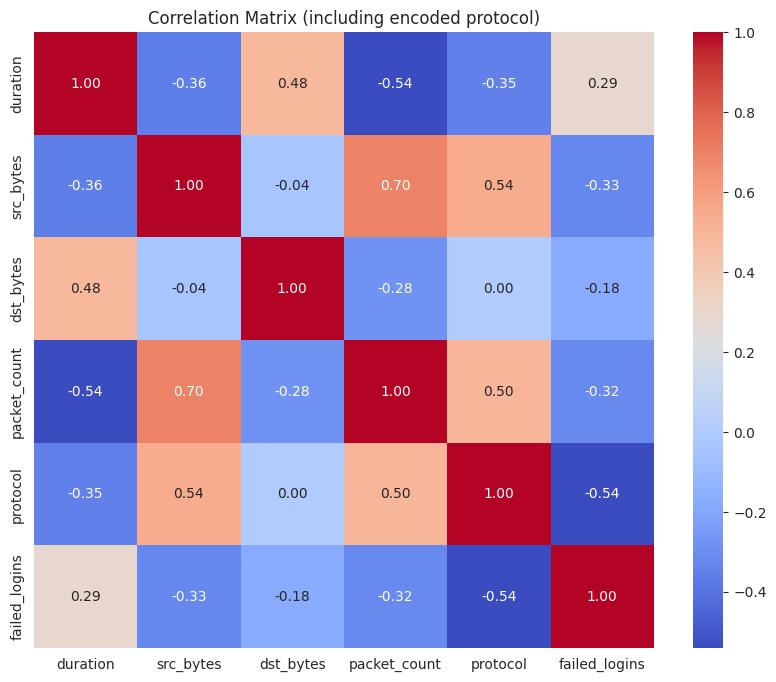

In [9]:
# Correlation heatmap (after encoding protocol)
df_encoded = df.copy()
df_encoded['protocol'] = df_encoded['protocol'].map({'TCP': 1, 'UDP': 0})

# Drop the target column to avoid the string→float conversion error
numeric_df = df_encoded.drop('attack_type', axis=1)

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (including encoded protocol)')
plt.show()

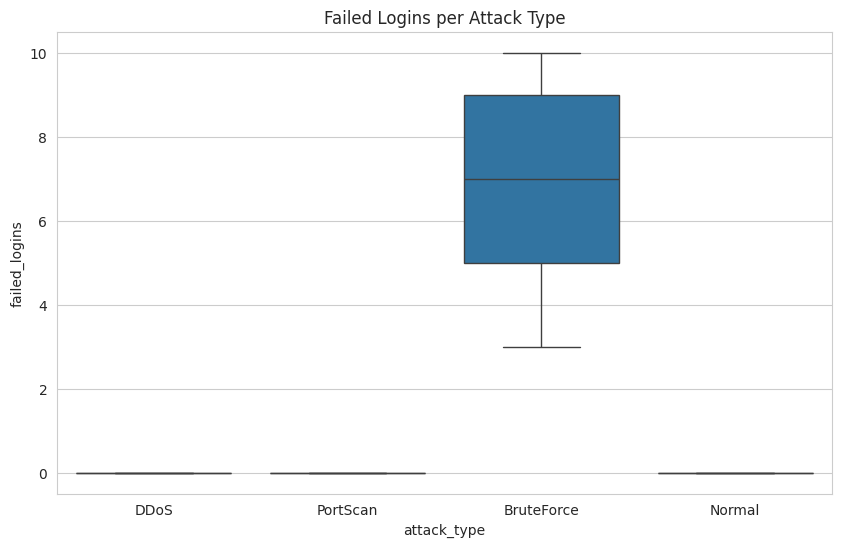

In [10]:
# Relationship between failed_logins and attack_type
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='attack_type', y='failed_logins')
plt.title('Failed Logins per Attack Type')
plt.show()

<Figure size 1000x600 with 0 Axes>

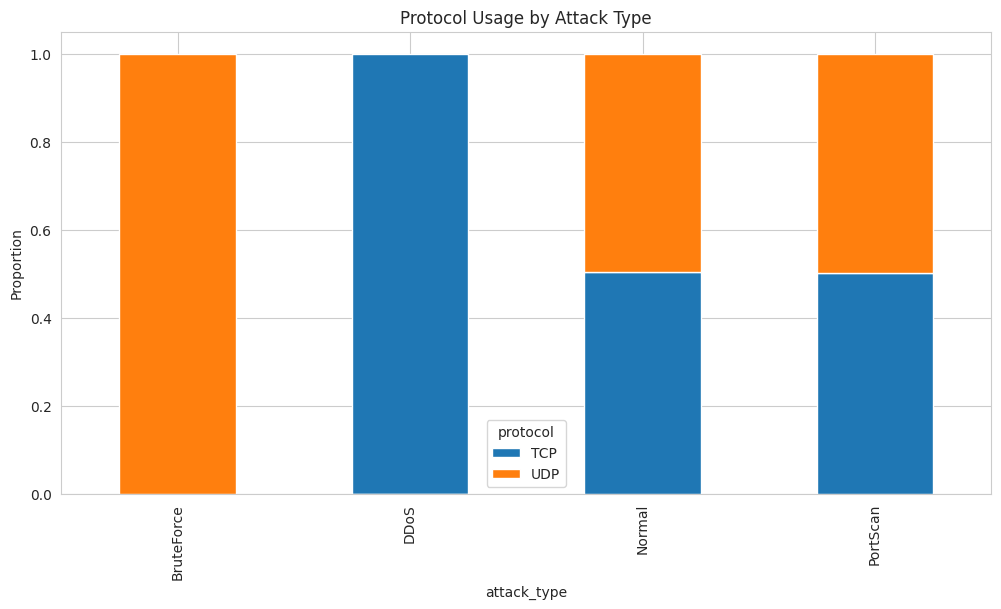

In [11]:
# Protocol distribution across classes
plt.figure(figsize=(10, 6))
pd.crosstab(df['attack_type'], df['protocol'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Protocol Usage by Attack Type')
plt.ylabel('Proportion')
plt.show()

# Data Preprocessing

In [12]:
# Separate features and target
X = df.drop('attack_type', axis=1)
y = df['attack_type']

# Encode categorical features (protocol)
le_protocol = LabelEncoder()
X['protocol'] = le_protocol.fit_transform(X['protocol'])  # TCP -> 1, UDP -> 0 ?

# Encode target labels
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)
target_names = le_target.classes_
print("Target classes:", target_names)

Target classes: ['BruteForce' 'DDoS' 'Normal' 'PortScan']


In [13]:
# Split into train and test sets (stratified to preserve class ratios)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 80000
Test set size: 20000


# Model Building and Evaluation

 We'll compare several classifiers:
 - Logistic Regression (simple baseline)
 - Decision Tree
 - Random Forest
 - XGBoost
 - LightGBM
 


In [14]:
# Helper function to evaluate a model
def evaluate_model(model, model_name, X_train, y_train, X_test, y_test, scale=False):
    if scale:
        # Pipeline with scaling
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', model)
        ])
    else:
        pipeline = model
    
    # Cross-validation accuracy (stratified 5-fold)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='accuracy')
    
    # Train on full training set and evaluate on test set
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    test_acc = accuracy_score(y_test, y_pred)
    
    print(f"\n{'='*60}")
    print(f"Model: {model_name}")
    print(f"Cross-validation accuracy (mean ± std): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"Test accuracy: {test_acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=target_names))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(cmap='Blues', xticks_rotation=45)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()
    
    return pipeline, test_acc

# Dictionary to store results
results = {}


## Logistic Regression


Model: Logistic Regression
Cross-validation accuracy (mean ± std): 0.9994 ± 0.0003
Test accuracy: 0.9997

Classification Report:
              precision    recall  f1-score   support

  BruteForce       1.00      1.00      1.00      5008
        DDoS       1.00      1.00      1.00      5015
      Normal       1.00      1.00      1.00      4975
    PortScan       1.00      1.00      1.00      5002

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



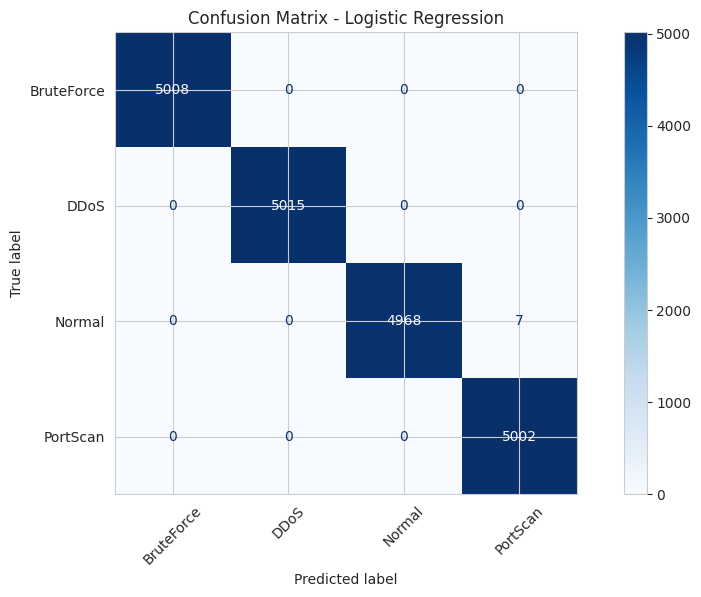

In [15]:
lr = LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42)
pipeline_lr, acc_lr = evaluate_model(lr, "Logistic Regression", X_train, y_train, X_test, y_test, scale=True)
results['Logistic Regression'] = acc_lr


## Decision Tree


Model: Decision Tree
Cross-validation accuracy (mean ± std): 1.0000 ± 0.0000
Test accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

  BruteForce       1.00      1.00      1.00      5008
        DDoS       1.00      1.00      1.00      5015
      Normal       1.00      1.00      1.00      4975
    PortScan       1.00      1.00      1.00      5002

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



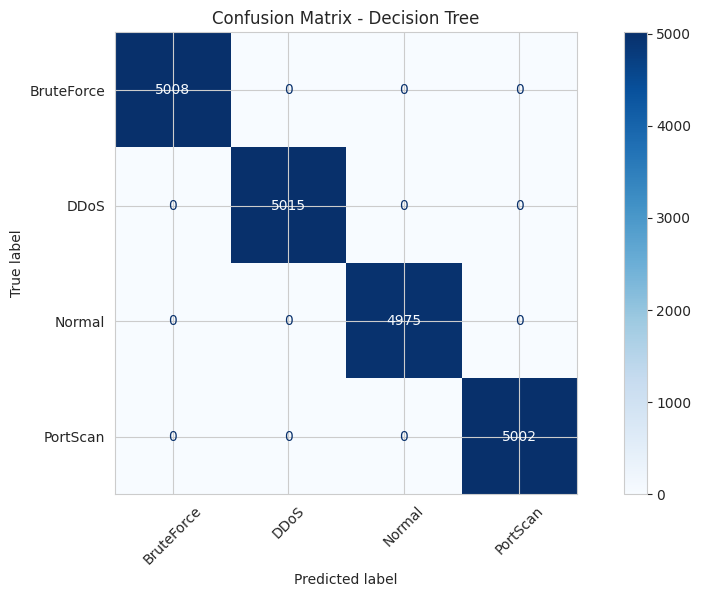

In [16]:
dt = DecisionTreeClassifier(random_state=42)
pipeline_dt, acc_dt = evaluate_model(dt, "Decision Tree", X_train, y_train, X_test, y_test, scale=False)
results['Decision Tree'] = acc_dt

## Random Forest


Model: Random Forest
Cross-validation accuracy (mean ± std): 1.0000 ± 0.0000
Test accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

  BruteForce       1.00      1.00      1.00      5008
        DDoS       1.00      1.00      1.00      5015
      Normal       1.00      1.00      1.00      4975
    PortScan       1.00      1.00      1.00      5002

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



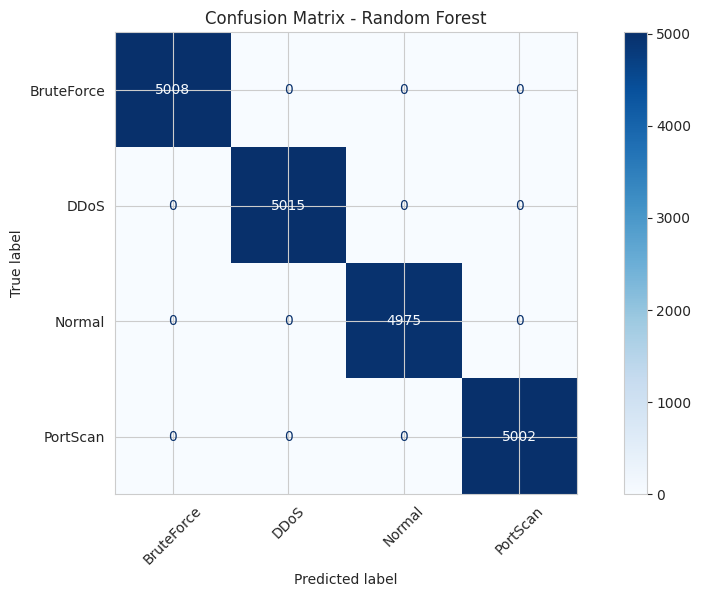

In [17]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
pipeline_rf, acc_rf = evaluate_model(rf, "Random Forest", X_train, y_train, X_test, y_test, scale=False)
results['Random Forest'] = acc_rf

## XGBoost


Model: XGBoost
Cross-validation accuracy (mean ± std): 1.0000 ± 0.0000
Test accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

  BruteForce       1.00      1.00      1.00      5008
        DDoS       1.00      1.00      1.00      5015
      Normal       1.00      1.00      1.00      4975
    PortScan       1.00      1.00      1.00      5002

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



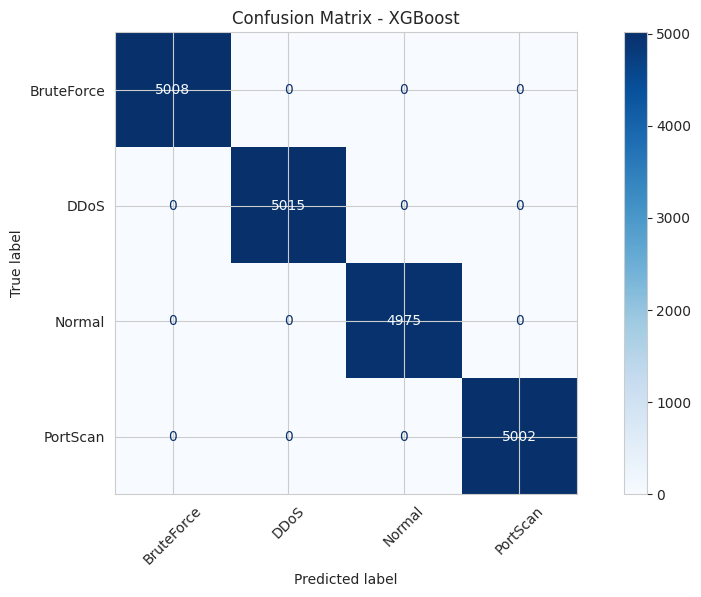

In [18]:
xgb = XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='mlogloss', random_state=42)
pipeline_xgb, acc_xgb = evaluate_model(xgb, "XGBoost", X_train, y_train, X_test, y_test, scale=False)
results['XGBoost'] = acc_xgb

## LightGBM


Model: LightGBM
Cross-validation accuracy (mean ± std): 1.0000 ± 0.0000
Test accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

  BruteForce       1.00      1.00      1.00      5008
        DDoS       1.00      1.00      1.00      5015
      Normal       1.00      1.00      1.00      4975
    PortScan       1.00      1.00      1.00      5002

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



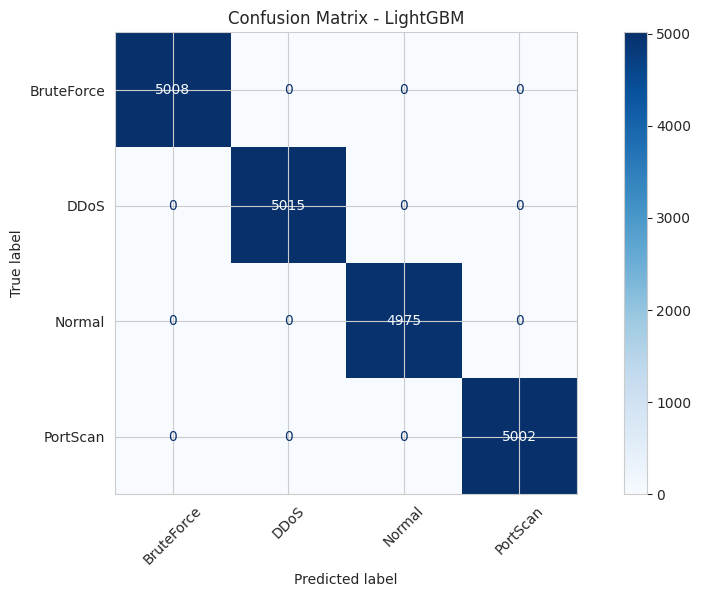

In [19]:
lgbm = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
pipeline_lgbm, acc_lgbm = evaluate_model(lgbm, "LightGBM", X_train, y_train, X_test, y_test, scale=False)
results['LightGBM'] = acc_lgbm


#  Model Comparison

              Model  Test Accuracy
      Decision Tree        1.00000
            XGBoost        1.00000
      Random Forest        1.00000
           LightGBM        1.00000
Logistic Regression        0.99965


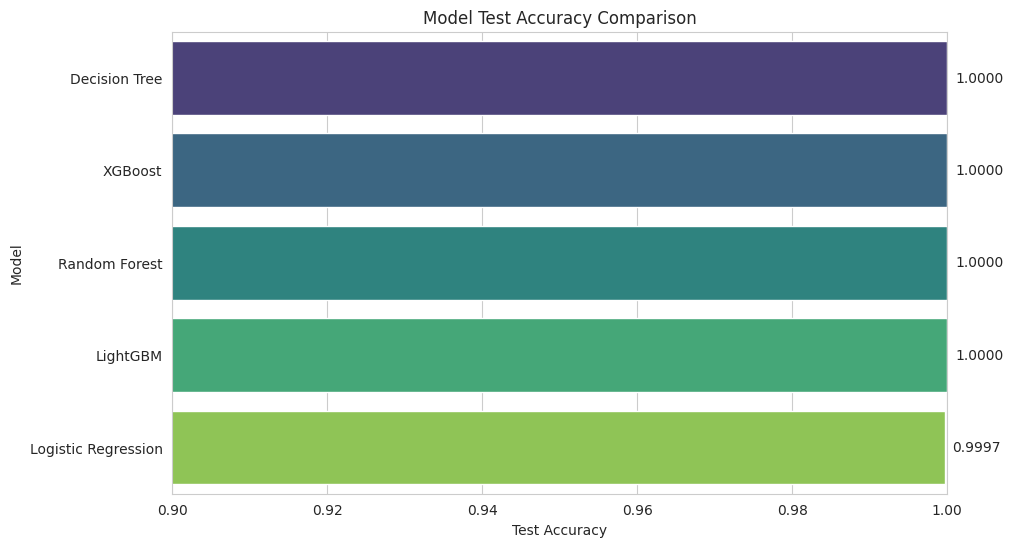

In [20]:
# Summarize results
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Test Accuracy'])
results_df = results_df.sort_values('Test Accuracy', ascending=False)
print(results_df.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Test Accuracy', y='Model', palette='viridis')
plt.title('Model Test Accuracy Comparison')
plt.xlim(0.9, 1.0)  # adjust based on results
for i, v in enumerate(results_df['Test Accuracy']):
    plt.text(v + 0.001, i, f"{v:.4f}", va='center')
plt.show()

# Feature Importance (Random Forest)


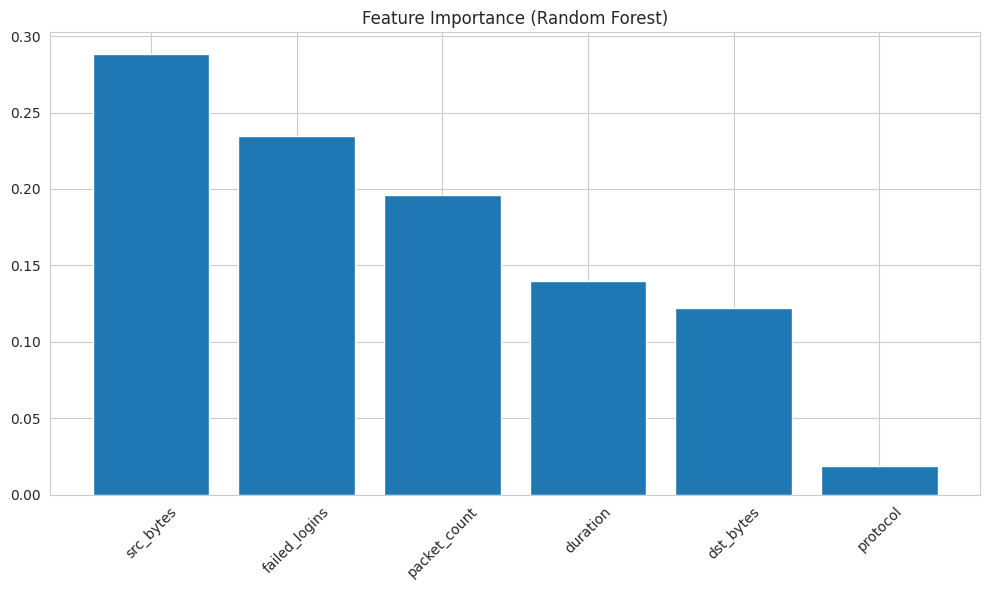

In [21]:
# Use the trained Random Forest to inspect feature importance
feature_names = X.columns
importances = pipeline_rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title('Feature Importance (Random Forest)')
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), feature_names[indices], rotation=45)
plt.tight_layout()
plt.show()

# Save the Best Model and Preprocessing Objects

In [22]:

# Create a directory for saved artifacts
os.makedirs('model_artifacts', exist_ok=True)

# --- Save the trained Random Forest model (pipeline_rf is a pure classifier, no scaler needed) ---
joblib.dump(pipeline_rf, 'model_artifacts/random_forest_model.pkl')
print("Random Forest model saved.")

# --- Save the label encoders ---
joblib.dump(le_protocol, 'model_artifacts/protocol_encoder.pkl')
joblib.dump(le_target, 'model_artifacts/target_encoder.pkl')
print("Label encoders saved.")

# --- Optionally save the StandardScaler if we want to use Logistic Regression in the future ---
# But we used it inside a pipeline, so we can extract the scaler from the pipeline:
scaler_lr = pipeline_lr.named_steps['scaler']
joblib.dump(scaler_lr, 'model_artifacts/scaler.pkl')
print("StandardScaler saved (for Logistic Regression).")

# --- Save the model comparison results as CSV ---
results_df.to_csv('model_artifacts/model_comparison.csv', index=False)
print("Model comparison results saved.")

# --- Save feature names and class names for reference ---
with open('model_artifacts/feature_names.txt', 'w') as f:
    f.write('\n'.join(X.columns))
with open('model_artifacts/target_classes.txt', 'w') as f:
    f.write('\n'.join(target_names))
print("Feature and class names saved.")

print("\nAll artifacts saved in 'model_artifacts/' folder.")

Random Forest model saved.
Label encoders saved.
StandardScaler saved (for Logistic Regression).
Model comparison results saved.
Feature and class names saved.

All artifacts saved in 'model_artifacts/' folder.


# Loading the Saved Model and Making Predictions

In [23]:

# --- Load artifacts ---
loaded_rf = joblib.load('model_artifacts/random_forest_model.pkl')
loaded_protocol_enc = joblib.load('model_artifacts/protocol_encoder.pkl')
loaded_target_enc = joblib.load('model_artifacts/target_encoder.pkl')

print("All artifacts loaded successfully.")

# --- Simulate a new network flow (example from test set) ---
# Take a random sample from the test set (original, unscaled)
sample_original = X_test.sample(1, random_state=42).copy()
print("\nNew network flow (raw):")
print(sample_original)

# Preprocess the sample (only protocol encoding is required)
# The original X_test already had protocol encoded, but if we receive raw data we do:
# sample_original['protocol'] = loaded_protocol_enc.transform(sample_original['protocol'])

# Make prediction (the model expects the same feature columns in the same order)
pred_encoded = loaded_rf.predict(sample_original)
pred_label = loaded_target_enc.inverse_transform(pred_encoded)[0]
print(f"\nPredicted attack type: {pred_label}")

# Get prediction probabilities
proba = loaded_rf.predict_proba(sample_original)
proba_df = pd.DataFrame(proba, columns=loaded_target_enc.classes_)
print("Class probabilities:")
print(proba_df.round(4))

All artifacts loaded successfully.

New network flow (raw):
       duration  src_bytes  dst_bytes  packet_count  protocol  failed_logins
23813         1        426         93           254         1              0

Predicted attack type: PortScan
Class probabilities:
   BruteForce  DDoS  Normal  PortScan
0         0.0   0.0     0.0       1.0


# Batch Inference Example

In [24]:


# Simulate loading a new data file (we'll use the test set without labels)
new_data = X_test.copy()  # in reality: pd.read_csv('new_flows.csv')

# Ensure protocol is encoded (if it's still in string form)
if new_data['protocol'].dtype == object:
    new_data['protocol'] = loaded_protocol_enc.transform(new_data['protocol'])

# Batch prediction
batch_predictions_encoded = loaded_rf.predict(new_data)
batch_predictions = loaded_target_enc.inverse_transform(batch_predictions_encoded)

# Add predictions to the dataframe
new_data_with_pred = new_data.copy()
new_data_with_pred['predicted_attack'] = batch_predictions
print(new_data_with_pred.head(10))

# Save the results
new_data_with_pred.to_csv('model_artifacts/batch_predictions.csv', index=False)
print("\nBatch predictions saved to 'model_artifacts/batch_predictions.csv'")

       duration  src_bytes  dst_bytes  packet_count  protocol  failed_logins  \
52156        38        672        486            71         1              5   
76295         1       5287        101           651         0              0   
75039        25        839        331            49         1              5   
34316        37       2038       1748            19         0              0   
94369         9        425        150           274         0              0   
52396         4        490        107           184         0              0   
17032         7        197        175           292         0              0   
66773         4        321         25            85         0              0   
87196         5       5857        418           344         0              0   
38231         6        205        185           155         1              0   

      predicted_attack  
52156       BruteForce  
76295             DDoS  
75039       BruteForce  
34316           Nor

# Complete Inference Function

In [25]:


def predict_network_flow(input_dict):
    """
    input_dict must contain keys:
    'duration', 'src_bytes', 'dst_bytes', 'packet_count', 'protocol' (string 'TCP' or 'UDP'),
    'failed_logins'
    Returns a tuple (predicted_class_label, probabilities_dataframe)
    """
    
    # Load artifacts (in production, load once outside the function)
    model = joblib.load('model_artifacts/random_forest_model.pkl')
    proto_enc = joblib.load('model_artifacts/protocol_encoder.pkl')
    target_enc = joblib.load('model_artifacts/target_encoder.pkl')

    # Convert to DataFrame
    input_df = pd.DataFrame([input_dict])
    
    # Encode protocol
    input_df['protocol'] = proto_enc.transform(input_df['protocol'])
    
    # Ensure column order matches training
    feature_order = ['duration', 'src_bytes', 'dst_bytes', 'packet_count', 'protocol', 'failed_logins']
    input_df = input_df[feature_order]
    
    # Predict
    pred_enc = model.predict(input_df)[0]
    pred_class = target_enc.inverse_transform([pred_enc])[0]
    
    proba = model.predict_proba(input_df)[0]
    proba_df = pd.DataFrame([proba], columns=target_enc.classes_)
    
    return pred_class, proba_df

# Test the function with a sample dictionary
sample_flow = {
    'duration': 2.3,
    'src_bytes': 1500,
    'dst_bytes': 200,
    'packet_count': 12,
    'protocol': 'TCP',
    'failed_logins': 0
}

pred_class, probs = predict_network_flow(sample_flow)
print(f"Predicted: {pred_class}")
print("Probabilities:")
print(probs.round(4))

Predicted: Normal
Probabilities:
   BruteForce  DDoS  Normal  PortScan
0         0.0  0.02    0.79      0.19


# Saving Additional Evaluation Metrics

In [26]:

y_test_pred = loaded_rf.predict(X_test)
report_dict = classification_report(y_test, y_test_pred, target_names=target_names, output_dict=True)
cm = confusion_matrix(y_test, y_test_pred).tolist()

with open('model_artifacts/classification_report.json', 'w') as f:
    json.dump(report_dict, f, indent=4)

with open('model_artifacts/confusion_matrix.json', 'w') as f:
    json.dump(cm, f, indent=4)

print("Evaluation metrics saved as JSON.")

Evaluation metrics saved as JSON.
